# Day 3 — Classification: Naive Bayes & Decision Tree

A complete walkthrough of Classification algorithms covering:
- **Part 1**: Naive Bayes with Scikit-Learn (Small Dataset)
- **Part 2**: Naive Bayes with Scikit-Learn (Actual Dataset — Titanic)
- **Part 3**: Decision Tree with Scikit-Learn (Small Dataset)
- **Part 4**: Decision Tree with Scikit-Learn (Actual Dataset — Titanic)
- **Part 5**: AutoML Classification with PyCaret

Each part includes **Confusion Matrix** and **Evaluation Metrics** (Accuracy, Precision, Recall, F1-Score).

In [1]:
# ── Common Imports ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
# Part 1 — Naive Bayes with Scikit-Learn (Small Dataset)

### What is Naive Bayes?
Naive Bayes is a **probabilistic classifier** based on **Bayes' Theorem** with the *naive* assumption that all features are **conditionally independent** given the class label.

$$P(C \mid X) = \frac{P(X \mid C) \cdot P(C)}{P(X)}$$

Where:
- $P(C \mid X)$ — Posterior probability of class $C$ given features $X$
- $P(X \mid C)$ — Likelihood of features given the class
- $P(C)$ — Prior probability of the class

We use **GaussianNB** from sklearn (assumes features follow a normal distribution).

**Small Dataset:** We create a simple weather-play tennis dataset.

In [2]:
# ── Part 1: Small Dataset — Weather → Play Tennis ────────────────

# Numeric encoding of: Outlook(Sunny=0,Overcast=1,Rainy=2)
#                      Temp(Hot=0,Mild=1,Cool=2)
#                      Humidity(High=0,Normal=1)
#                      Wind(Weak=0,Strong=1)
#                      Play(No=0,Yes=1)

data = {
    'Outlook':   [0,0,1,2,2,2,1,0,0,2,0,1,1,2],
    'Temp':      [0,0,0,1,2,2,2,1,2,1,1,1,0,1],
    'Humidity':  [0,0,0,0,1,1,1,0,1,1,1,0,1,0],
    'Wind':      [0,1,0,0,0,1,1,0,0,0,1,1,0,1],
    'Play':      [0,0,1,1,1,0,1,0,1,1,1,1,1,0]
}

df_small = pd.DataFrame(data)

# Map back for readability
outlook_map   = {0:'Sunny', 1:'Overcast', 2:'Rainy'}
temp_map      = {0:'Hot', 1:'Mild', 2:'Cool'}
humidity_map  = {0:'High', 1:'Normal'}
wind_map      = {0:'Weak', 1:'Strong'}
play_map      = {0:'No', 1:'Yes'}

df_display = df_small.copy()
df_display['Outlook']  = df_display['Outlook'].map(outlook_map)
df_display['Temp']     = df_display['Temp'].map(temp_map)
df_display['Humidity'] = df_display['Humidity'].map(humidity_map)
df_display['Wind']     = df_display['Wind'].map(wind_map)
df_display['Play']     = df_display['Play'].map(play_map)

print('=== Play Tennis Dataset (14 samples) ===')
print(df_display.to_string(index=False))
print(f'\nClass Distribution:\n{df_display["Play"].value_counts()}')

=== Play Tennis Dataset (14 samples) ===
 Outlook Temp Humidity   Wind Play
   Sunny  Hot     High   Weak   No
   Sunny  Hot     High Strong   No
Overcast  Hot     High   Weak  Yes
   Rainy Mild     High   Weak  Yes
   Rainy Cool   Normal   Weak  Yes
   Rainy Cool   Normal Strong   No
Overcast Cool   Normal Strong  Yes
   Sunny Mild     High   Weak   No
   Sunny Cool   Normal   Weak  Yes
   Rainy Mild   Normal   Weak  Yes
   Sunny Mild   Normal Strong  Yes
Overcast Mild     High Strong  Yes
Overcast  Hot   Normal   Weak  Yes
   Rainy Mild     High Strong   No

Class Distribution:
Play
Yes    9
No     5
Name: count, dtype: int64


In [3]:
# ── Train Naive Bayes on Small Dataset ───────────────────────────

X_small = df_small.drop('Play', axis=1)
y_small = df_small['Play']

# Using all data for training (only 14 rows — demonstrate on training set)
# Also do a leave-2-out split to show metrics meaningfully
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small, test_size=0.3, random_state=42
)

# Train Gaussian Naive Bayes
gnb_small = GaussianNB()
gnb_small.fit(X_train, y_train)

y_pred_small = gnb_small.predict(X_test)

print('=== Predictions on Test Set ===')
results = pd.DataFrame({'Actual': y_test.map(play_map).values,
                         'Predicted': pd.Series(y_pred_small).map(play_map).values})
print(results.to_string(index=False))

# Class probabilities for each test sample
proba = gnb_small.predict_proba(X_test)
print('\n=== Class Probabilities (P(No), P(Yes)) ===')
print(pd.DataFrame(proba, columns=['P(No)', 'P(Yes)']).round(3).to_string(index=False))

=== Predictions on Test Set ===
Actual Predicted
   Yes       Yes
   Yes        No
    No        No
   Yes       Yes
    No       Yes

=== Class Probabilities (P(No), P(Yes)) ===
 P(No)  P(Yes)
   0.0     1.0
   1.0     0.0
   1.0     0.0
   0.0     1.0
   0.0     1.0


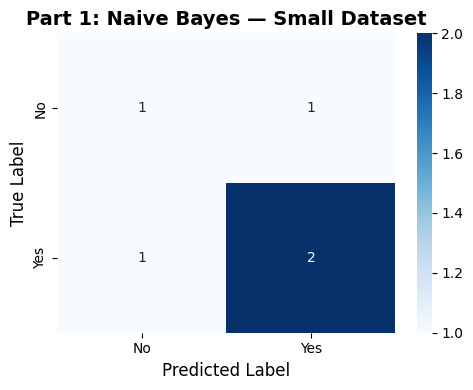


──────────────────────────────────────────────────
  Part 1: Naive Bayes — Small Dataset
──────────────────────────────────────────────────
  Accuracy  : 0.6000
  Precision : 0.6000
  Recall    : 0.6000
  F1-Score  : 0.6000
──────────────────────────────────────────────────

Detailed Classification Report:
              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



In [ ]:
# ── Confusion Matrix — Part 1 ────────────────────────────────────

cm1 = confusion_matrix(y_test, y_pred_small)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Part 1: Naive Bayes — Small Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Evaluation Metrics — Part 1 ──────────────────────────────────

print('\n' + '─'*50)
print('  Part 1: Naive Bayes — Small Dataset')
print('─'*50)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_small):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_small, average="weighted", zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_small, average="weighted", zero_division=0):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_small, average="weighted", zero_division=0):.4f}')
print('─'*50)
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_small, target_names=['No', 'Yes'], zero_division=0))

---
# Part 2 — Naive Bayes with Scikit-Learn (Actual Dataset — Titanic)

We use the **Titanic dataset** to predict passenger **survival** (0 = Did not survive, 1 = Survived).

### Preprocessing Steps:
1. Drop irrelevant columns (Name, Ticket, Cabin, PassengerId)
2. Encode categorical features (Sex, Embarked)
3. Fill missing values
4. Train/Test split (80/20)
5. Fit `GaussianNB` and evaluate

In [2]:
# ── Part 2: Load & Preprocess Titanic Dataset ────────────────────

df_titanic = pd.read_csv('data/titanic.csv')

print('=== Titanic Dataset — First 5 rows ===')
print(df_titanic.head())
print(f'\nShape: {df_titanic.shape}')
print(f'\nMissing Values:\n{df_titanic.isnull().sum()}')
print(f'\nClass Distribution (Survived):\n{df_titanic["Survived"].value_counts()}')

NameError: name 'pd' is not defined

In [15]:
# ── Preprocessing Step 1: Create Working Copy and Drop Columns ───

df2 = df_titanic.copy()

# Drop irrelevant / high-cardinality columns
drop_cols = [col for col in ['PassengerId', 'Name', 'Ticket', 'Cabin'] if col in df2.columns]
df2 = df2.drop(columns=drop_cols)

print('=== After Dropping Irrelevant Columns ===')
print(df2.head())
print(f'\nShape: {df2.shape}')
print(f'\nColumns:\n{list(df2.columns)}')

=== After Dropping Irrelevant Columns ===
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S

Shape: (891, 8)

Columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [16]:
# ── Preprocessing Step 2: Fill Missing Values ────────────────────

df2['Age'] = df2['Age'].fillna(df2['Age'].median())
df2['Fare'] = df2['Fare'].fillna(df2['Fare'].median())
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])
df2['SibSp'] = df2['SibSp'].fillna(0)
df2['Parch'] = df2['Parch'].fillna(0)

print('=== After Filling Missing Values ===')
print(df2.isnull().sum())
print(f'\nTotal missing values: {df2.isnull().sum().sum()}')

=== After Filling Missing Values ===
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Total missing values: 0


In [17]:
# ── Preprocessing Step 3: Feature Engineering ────────────────────

# Family size
df2['FamilySize'] = df2['SibSp'] + df2['Parch'] + 1

# Is alone
df2['IsAlone'] = (df2['FamilySize'] == 1).astype(int)

# Age group bins
df2['AgeGroup'] = pd.cut(
    df2['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# Fare band bins
df2['FareBand'] = pd.qcut(df2['Fare'], q=4, labels=[0, 1, 2, 3]).astype(int)

print('=== After Feature Engineering ===')
print(df2[['FamilySize', 'IsAlone', 'AgeGroup', 'FareBand']].head())

=== After Feature Engineering ===
   FamilySize  IsAlone  AgeGroup  FareBand
0           2        0         2         0
1           2        0         3         3
2           1        1         2         1
3           2        0         2         3
4           1        1         2         1


In [18]:
# ── Preprocessing Step 4: Encode Categorical Columns ─────────────

le = LabelEncoder()
for col in ['Sex', 'Embarked']:
    if col in df2.columns:
        df2[col] = le.fit_transform(df2[col].astype(str))

print('=== After Encoding Categorical Columns ===')
print(df2[['Sex', 'Embarked']].head())
print(f'\nData types:\n{df2.dtypes}')

=== After Encoding Categorical Columns ===
   Sex  Embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2

Data types:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
FamilySize      int64
IsAlone         int64
AgeGroup        int64
FareBand        int64
dtype: object


In [19]:
# ── Preprocessing Step 5: Final Cleanup and Validation ───────────

# Drop original columns replaced by engineered features
df2 = df2.drop(columns=['Age', 'Fare', 'SibSp', 'Parch'])

# Final NaN check
remaining_nan = df2.isnull().sum().sum()
if remaining_nan > 0:
    print(f'WARNING: {remaining_nan} NaN values remain. Dropping those rows.')
    df2 = df2.dropna()

print('=== Final Preprocessed Dataset ===')
print(df2.head())
print(f'\nShape after preprocessing: {df2.shape}')
print(f'\nFeatures: {list(df2.columns)}')
print(f'\nMissing values remaining: {df2.isnull().sum().sum()}')

=== Final Preprocessed Dataset ===
   Survived  Pclass  Sex  Embarked  FamilySize  IsAlone  AgeGroup  FareBand
0         0       3    1         2           2        0         2         0
1         1       1    0         0           2        0         3         3
2         1       3    0         2           1        1         2         1
3         1       1    0         2           2        0         2         3
4         0       3    1         2           1        1         2         1

Shape after preprocessing: (891, 8)

Features: ['Survived', 'Pclass', 'Sex', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareBand']

Missing values remaining: 0


In [13]:
# ── Train Gaussian Naive Bayes on Titanic ────────────────────────

X_titanic = df2.drop('Survived', axis=1)
y_titanic = df2['Survived']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42
)

gnb_titanic = GaussianNB()
gnb_titanic.fit(X_train2, y_train2)

y_pred2 = gnb_titanic.predict(X_test2)

print(f'Training samples : {X_train2.shape[0]}')
print(f'Testing  samples : {X_test2.shape[0]}')
print(f'\nSample Predictions (first 10):')
print(pd.DataFrame({'Actual': y_test2.values[:10], 'Predicted': y_pred2[:10]}))

Training samples : 712
Testing  samples : 179

Sample Predictions (first 10):
   Actual  Predicted
0       1          0
1       0          0
2       0          0
3       1          1
4       1          1
5       1          1
6       1          1
7       0          0
8       1          1
9       1          1


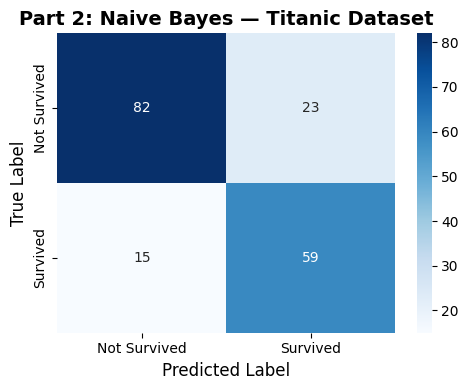

In [20]:
# ── Confusion Matrix — Part 2 ────────────────────────────────────

cm2 = confusion_matrix(y_test2, y_pred2)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'], ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Part 2: Naive Bayes — Titanic Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# ── Evaluation Metrics — Part 2 ──────────────────────────────────

print('\n' + '─'*50)
print('  Part 2: Naive Bayes — Titanic Dataset')
print('─'*50)
print(f'  Accuracy  : {accuracy_score(y_test2, y_pred2):.4f}')
print(f'  Precision : {precision_score(y_test2, y_pred2, average="weighted", zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test2, y_pred2, average="weighted", zero_division=0):.4f}')
print(f'  F1-Score  : {f1_score(y_test2, y_pred2, average="weighted", zero_division=0):.4f}')
print('─'*50)
print('\nDetailed Classification Report:')
print(classification_report(y_test2, y_pred2, target_names=['Not Survived', 'Survived'], zero_division=0))


──────────────────────────────────────────────────
  Part 2: Naive Bayes — Titanic Dataset
──────────────────────────────────────────────────
  Accuracy  : 0.7877
  Precision : 0.7933
  Recall    : 0.7877
  F1-Score  : 0.7889
──────────────────────────────────────────────────

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.85      0.78      0.81       105
    Survived       0.72      0.80      0.76        74

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.79      0.79      0.79       179



---
# Part 3 — Decision Tree with Scikit-Learn (Small Dataset)

### What is a Decision Tree?
A Decision Tree splits the dataset into subsets based on feature values, forming a **tree-like structure**. At each node it picks the feature that maximises **Information Gain** (using entropy or Gini impurity).

$$\text{Entropy}(S) = -\sum_{c} p_c \log_2(p_c)$$

$$\text{Information Gain}(S, A) = \text{Entropy}(S) - \sum_{v} \frac{|S_v|}{|S|} \cdot \text{Entropy}(S_v)$$

We reuse the same **Play Tennis** small dataset to directly compare with Naive Bayes.

In [22]:
# ── Part 3: Decision Tree on Small Dataset ───────────────────────

dt_small = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt_small.fit(X_train, y_train)   # Reuse the same train/test split from Part 1

y_pred3 = dt_small.predict(X_test)

print('=== Decision Tree — Play Tennis Dataset ===')
print(f'Tree Depth : {dt_small.get_depth()}')
print(f'Num Leaves : {dt_small.get_n_leaves()}')
print(f'\nFeature Importances:')
feat_imp = pd.Series(dt_small.feature_importances_,
                     index=X_small.columns).sort_values(ascending=False)
print(feat_imp.to_string())

print('\n=== Predictions on Test Set ===')
results3 = pd.DataFrame({'Actual': y_test.map(play_map).values,
                          'Predicted': pd.Series(y_pred3).map(play_map).values})
print(results3.to_string(index=False))

=== Decision Tree — Play Tennis Dataset ===
Tree Depth : 3
Num Leaves : 4

Feature Importances:
Humidity    0.412589
Wind        0.333333
Outlook     0.254078
Temp        0.000000

=== Predictions on Test Set ===
Actual Predicted
   Yes       Yes
   Yes        No
    No        No
   Yes       Yes
    No       Yes


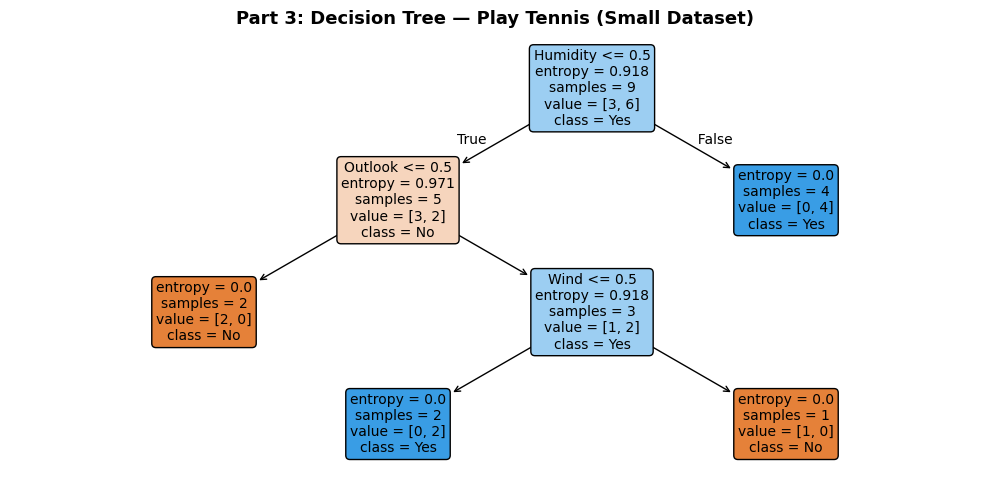

In [23]:
# ── Visualise the Decision Tree ───────────────────────────────────

feature_names = list(X_small.columns)
class_names   = ['No', 'Yes']

fig, ax = plt.subplots(figsize=(10, 5))
plot_tree(dt_small,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
ax.set_title('Part 3: Decision Tree — Play Tennis (Small Dataset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

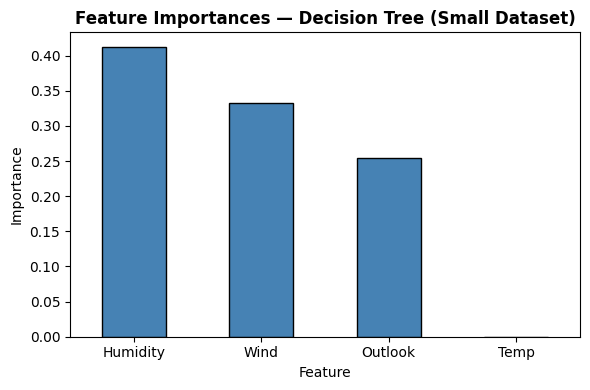

In [24]:
# ── Feature Importance Bar Chart ─────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 4))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Feature Importances — Decision Tree (Small Dataset)', fontweight='bold')
ax.set_ylabel('Importance')
ax.set_xlabel('Feature')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

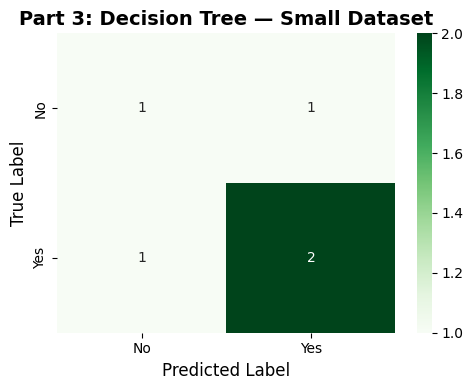

In [25]:
# ── Confusion Matrix — Part 3 ────────────────────────────────────

cm3 = confusion_matrix(y_test, y_pred3)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Part 3: Decision Tree — Small Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# ── Evaluation Metrics — Part 3 ──────────────────────────────────

print('\n' + '─'*50)
print('  Part 3: Decision Tree — Small Dataset')
print('─'*50)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred3):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred3, average="weighted", zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred3, average="weighted", zero_division=0):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred3, average="weighted", zero_division=0):.4f}')
print('─'*50)
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred3, target_names=['No', 'Yes'], zero_division=0))


──────────────────────────────────────────────────
  Part 3: Decision Tree — Small Dataset
──────────────────────────────────────────────────
  Accuracy  : 0.6000
  Precision : 0.6000
  Recall    : 0.6000
  F1-Score  : 0.6000
──────────────────────────────────────────────────

Detailed Classification Report:
              precision    recall  f1-score   support

          No       0.50      0.50      0.50         2
         Yes       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



---
# Part 4 — Decision Tree with Scikit-Learn (Actual Dataset — Titanic)

We apply the **Decision Tree Classifier** on the same preprocessed **Titanic dataset** used in Part 2.

We also tune `max_depth` and visualise the tree structure and feature importances.

In [27]:
# ── Part 4: Decision Tree on Titanic Dataset ─────────────────────

dt_titanic = DecisionTreeClassifier(criterion='gini', max_depth=5,
                                     min_samples_split=10, random_state=42)
dt_titanic.fit(X_train2, y_train2)

y_pred4 = dt_titanic.predict(X_test2)

print('=== Decision Tree — Titanic Dataset ===')
print(f'Tree Depth : {dt_titanic.get_depth()}')
print(f'Num Leaves : {dt_titanic.get_n_leaves()}')

# Feature importances
feat_imp4 = pd.Series(dt_titanic.feature_importances_,
                      index=X_titanic.columns).sort_values(ascending=False)
print(f'\nFeature Importances:\n{feat_imp4.to_string()}')

=== Decision Tree — Titanic Dataset ===
Tree Depth : 5
Num Leaves : 23

Feature Importances:
Sex           0.562180
Pclass        0.201412
FamilySize    0.120054
AgeGroup      0.072130
FareBand      0.018886
Embarked      0.014513
IsAlone       0.010825


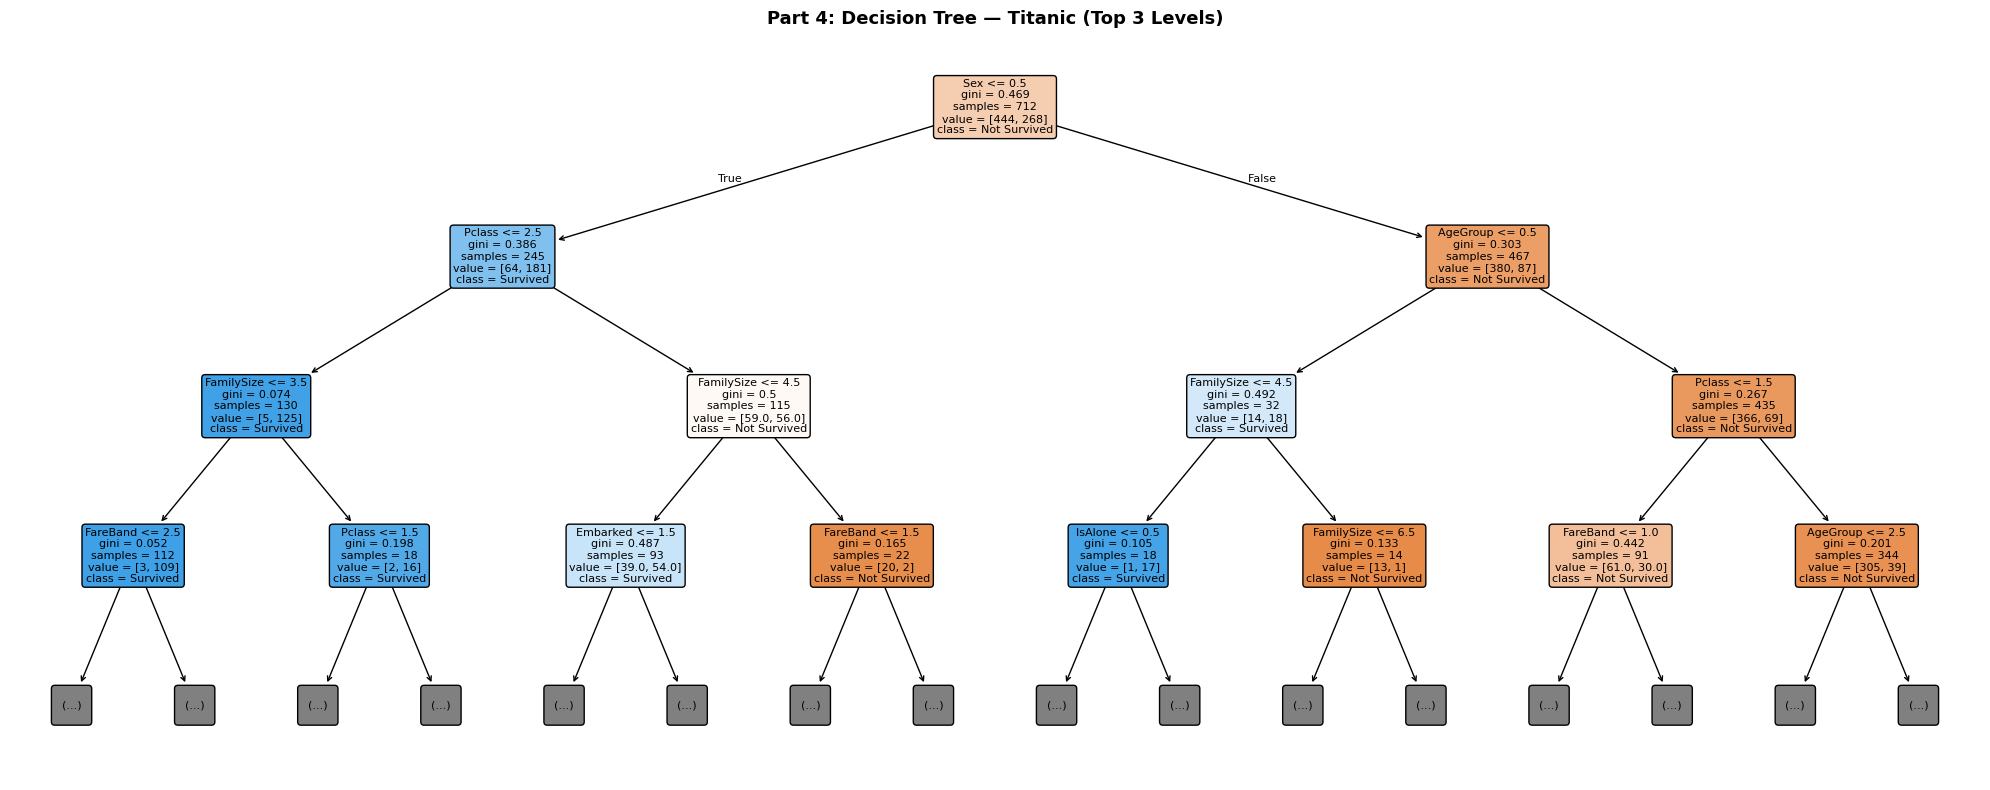

In [28]:
# ── Visualise Decision Tree (Titanic) ────────────────────────────

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_titanic,
          feature_names=list(X_titanic.columns),
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3,   # show top 3 levels for readability
          ax=ax)
ax.set_title('Part 4: Decision Tree — Titanic (Top 3 Levels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

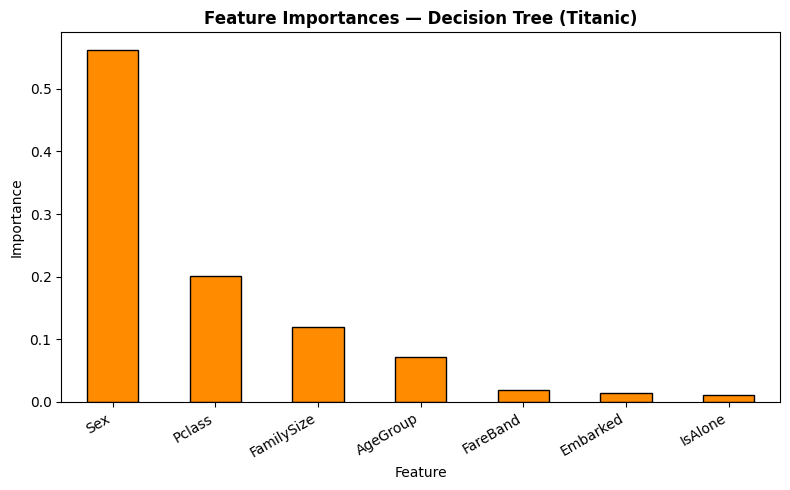

In [29]:
# ── Feature Importance Bar Chart (Titanic) ───────────────────────

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp4.plot(kind='bar', color='darkorange', edgecolor='black', ax=ax)
ax.set_title('Feature Importances — Decision Tree (Titanic)', fontweight='bold')
ax.set_ylabel('Importance')
ax.set_xlabel('Feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

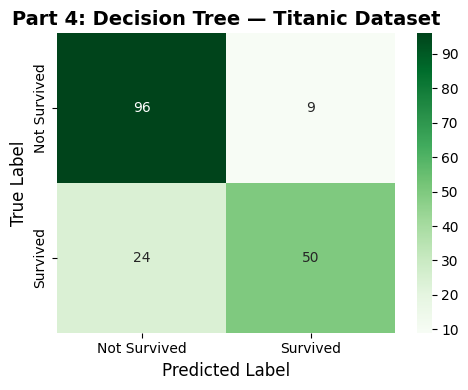

In [30]:
# ── Confusion Matrix — Part 4 ────────────────────────────────────

cm4 = confusion_matrix(y_test2, y_pred4)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'], ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Part 4: Decision Tree — Titanic Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# ── Evaluation Metrics — Part 4 ──────────────────────────────────

print('\n' + '─'*50)
print('  Part 4: Decision Tree — Titanic Dataset')
print('─'*50)
print(f'  Accuracy  : {accuracy_score(y_test2, y_pred4):.4f}')
print(f'  Precision : {precision_score(y_test2, y_pred4, average="weighted", zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test2, y_pred4, average="weighted", zero_division=0):.4f}')
print(f'  F1-Score  : {f1_score(y_test2, y_pred4, average="weighted", zero_division=0):.4f}')
print('─'*50)
print('\nDetailed Classification Report:')
print(classification_report(y_test2, y_pred4, target_names=['Not Survived', 'Survived'], zero_division=0))


──────────────────────────────────────────────────
  Part 4: Decision Tree — Titanic Dataset
──────────────────────────────────────────────────
  Accuracy  : 0.8156
  Precision : 0.8196
  Recall    : 0.8156
  F1-Score  : 0.8114
──────────────────────────────────────────────────

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.80      0.91      0.85       105
    Survived       0.85      0.68      0.75        74

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



---
## Model Comparison — Naive Bayes vs Decision Tree (Titanic)

Side-by-side comparison of both models on the same test set.

=== Model Comparison on Titanic Test Set ===
        Model  Accuracy  Precision  Recall  F1-Score
  Naive Bayes    0.7877     0.7933  0.7877    0.7889
Decision Tree    0.8156     0.8196  0.8156    0.8114


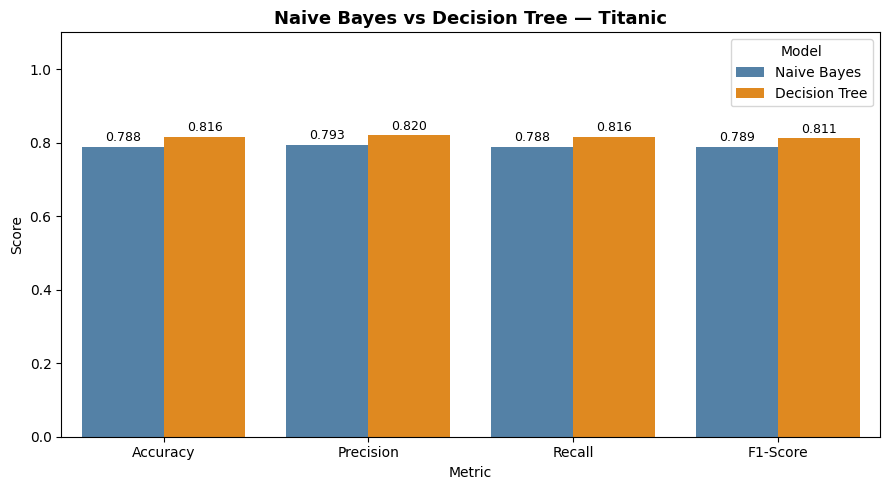

In [32]:
# ── Side-by-side Comparison ──────────────────────────────────────

models   = ['Naive Bayes', 'Decision Tree']
preds    = [y_pred2, y_pred4]
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

rows = []
for name, pred in zip(models, preds):
    rows.append([
        name,
        round(accuracy_score(y_test2, pred), 4),
        round(precision_score(y_test2, pred, average='weighted', zero_division=0), 4),
        round(recall_score(y_test2, pred, average='weighted', zero_division=0), 4),
        round(f1_score(y_test2, pred, average='weighted', zero_division=0), 4),
    ])

comparison_df = pd.DataFrame(rows, columns=['Model'] + metrics)
print('=== Model Comparison on Titanic Test Set ===')
print(comparison_df.to_string(index=False))

# Bar chart
comp_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=comp_melted, x='Metric', y='Score', hue='Model',
            palette=['steelblue', 'darkorange'], ax=ax)
ax.set_title('Naive Bayes vs Decision Tree — Titanic', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=2)
plt.tight_layout()
plt.show()

---
# Part 5 — AutoML Classification with PyCaret

**PyCaret** is a low-code machine learning library that automates the end-to-end ML workflow.

### What PyCaret does automatically:
- Imputation of missing values
- Encoding of categorical variables
- Feature scaling / normalization
- Train/test split & cross-validation
- **`compare_models()`** — trains & ranks all available classifiers
- `plot_model()` — generates evaluation plots

> **Note:** If PyCaret is not installed, run the cell below first.

In [ ]:
# ── Install PyCaret (run only once) ──────────────────────────────
# Uncomment and run this cell if pycaret is not yet installed:

# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pycaret', '-q'])
print('If PyCaret is not installed, uncomment the lines above and run this cell first.')

In [6]:
# ── PyCaret Data Loading ──────────────────────────────────────────
import pandas as pd
df_pyc = pd.read_csv('data/titanic.csv')

# Drop only columns that PyCaret cannot use (too many unique values)
pycaret_drop_cols = [col for col in ['PassengerId', 'Name', 'Ticket', 'Cabin'] if col in df_pyc.columns]
df_pyc = df_pyc.drop(columns=pycaret_drop_cols)

print('=== PyCaret Input Data ===')
print(df_pyc.head())
print(f'\nShape: {df_pyc.shape}')
print(f'\nColumns: {list(df_pyc.columns)}')

=== PyCaret Input Data ===
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S

Shape: (891, 8)

Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [7]:
# ── PyCaret Setup ────────────────────────────────────────────────
from pycaret.classification import (
    setup, compare_models, pull, predict_model,
    plot_model, finalize_model, create_model
)

# PyCaret setup on the prepared dataset
clf_setup = setup(
    data       = df_pyc,
    target     = 'Survived',
    session_id = 42,
    train_size = 0.8,
    verbose    = False
)

print('PyCaret setup complete!')

PyCaret setup complete!


In [8]:
# ── Compare All Classification Models ────────────────────────────

best_model = compare_models(n_select=1, sort='F1', verbose=True)

print(f'\nBest Model: {type(best_model).__name__}')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8316,0.8820,0.7036,0.8303,0.7556,0.6304,0.6391,0.0110
lightgbm,Light Gradient Boosting Machine,0.8091,0.8722,0.7295,0.7637,0.7404,0.5908,0.5964,0.4050
ada,Ada Boost Classifier,0.8035,0.8503,0.7331,0.7515,0.7399,0.5823,0.5847,0.0100
rf,Random Forest Classifier,0.8034,0.8591,0.7181,0.7562,0.7336,0.5786,0.5818,0.0180
et,Extra Trees Classifier,0.7950,0.8362,0.7217,0.7360,0.7259,0.5627,0.5655,0.0160
lr,Logistic Regression,0.7978,0.8570,0.7034,0.7569,0.7239,0.5657,0.5711,0.8160
ridge,Ridge Classifier,0.7963,0.8569,0.7033,0.7531,0.7223,0.5628,0.5677,0.0050
lda,Linear Discriminant Analysis,0.7963,0.8569,0.7033,0.7531,0.7223,0.5628,0.5677,0.0060
nb,Naive Bayes,0.7950,0.8197,0.6963,0.7541,0.7197,0.5593,0.5643,0.0050
dt,Decision Tree Classifier,0.7852,0.7678,0.7152,0.7188,0.7118,0.5419,0.5466,0.0050



Best Model: GradientBoostingClassifier


In [9]:
# ── Create Naive Bayes & Decision Tree in PyCaret ────────────────

nb_pyc = create_model('nb', verbose=False)
dt_pyc = create_model('dt', verbose=False)

print('Naive Bayes Results:')
print(pull())

print('\nDecision Tree Results:')
_ = create_model('dt', verbose=True)

Naive Bayes Results:
      Accuracy     AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                          
0       0.6944  0.6660  0.4643  0.6500  0.5417  0.3219  0.3322
1       0.8056  0.7869  0.7500  0.7500  0.7500  0.5909  0.5909
2       0.7887  0.7699  0.6786  0.7600  0.7170  0.5493  0.5515
3       0.7042  0.6553  0.4815  0.6500  0.5532  0.3394  0.3479
4       0.7606  0.7323  0.7037  0.6786  0.6909  0.4956  0.4958
5       0.8169  0.8253  0.8889  0.7059  0.7869  0.6301  0.6429
6       0.8310  0.8194  0.8148  0.7586  0.7857  0.6465  0.6476
7       0.8451  0.8447  0.8519  0.7667  0.8070  0.6782  0.6808
8       0.7887  0.7614  0.6667  0.7500  0.7059  0.5419  0.5442
9       0.8169  0.8165  0.8519  0.7188  0.7797  0.6249  0.6316
Mean    0.7852  0.7678  0.7152  0.7188  0.7118  0.5419  0.5466
Std     0.0485  0.0624  0.1414  0.0433  0.0899  0.1176  0.1161

Decision Tree Results:


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6944,0.6660,0.4643,0.6500,0.5417,0.3219,0.3322
1,0.8056,0.7869,0.7500,0.7500,0.7500,0.5909,0.5909
2,0.7887,0.7699,0.6786,0.7600,0.7170,0.5493,0.5515
3,0.7042,0.6553,0.4815,0.6500,0.5532,0.3394,0.3479
4,0.7606,0.7323,0.7037,0.6786,0.6909,0.4956,0.4958
5,0.8169,0.8253,0.8889,0.7059,0.7869,0.6301,0.6429
6,0.8310,0.8194,0.8148,0.7586,0.7857,0.6465,0.6476
7,0.8451,0.8447,0.8519,0.7667,0.8070,0.6782,0.6808
8,0.7887,0.7614,0.6667,0.7500,0.7059,0.5419,0.5442


=== Naive Bayes Confusion Matrix (PyCaret) ===


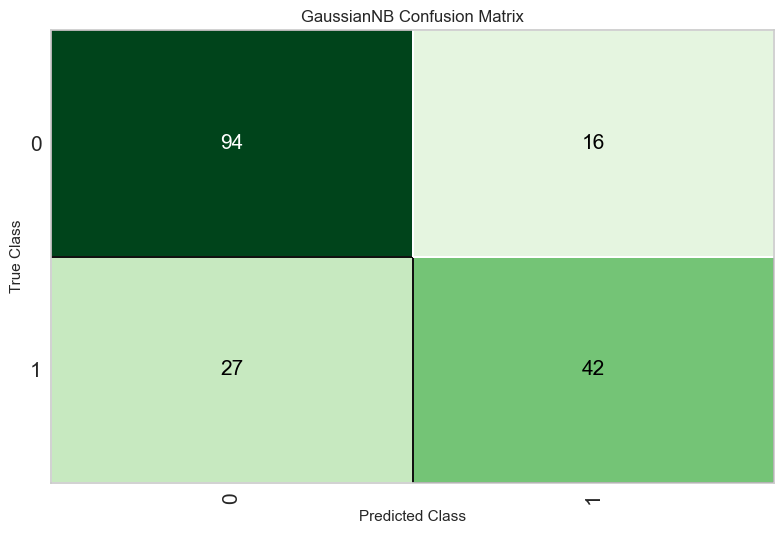

In [10]:
# ── Confusion Matrix — Naive Bayes (PyCaret) ─────────────────────

print('=== Naive Bayes Confusion Matrix (PyCaret) ===')
plot_model(nb_pyc, plot='confusion_matrix', plot_kwargs={'percent': False})

=== Decision Tree Confusion Matrix (PyCaret) ===


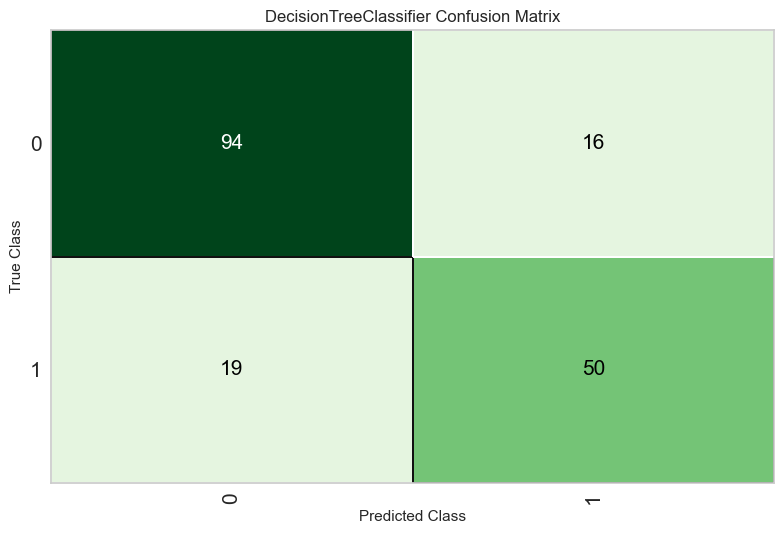

In [11]:
# ── Confusion Matrix — Decision Tree (PyCaret) ───────────────────

print('=== Decision Tree Confusion Matrix (PyCaret) ===')
plot_model(dt_pyc, plot='confusion_matrix', plot_kwargs={'percent': False})

=== ROC-AUC — Naive Bayes ===


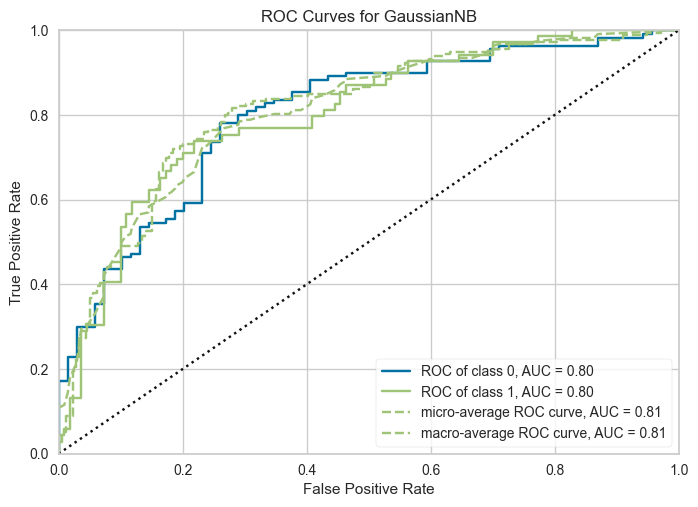

=== ROC-AUC — Decision Tree ===


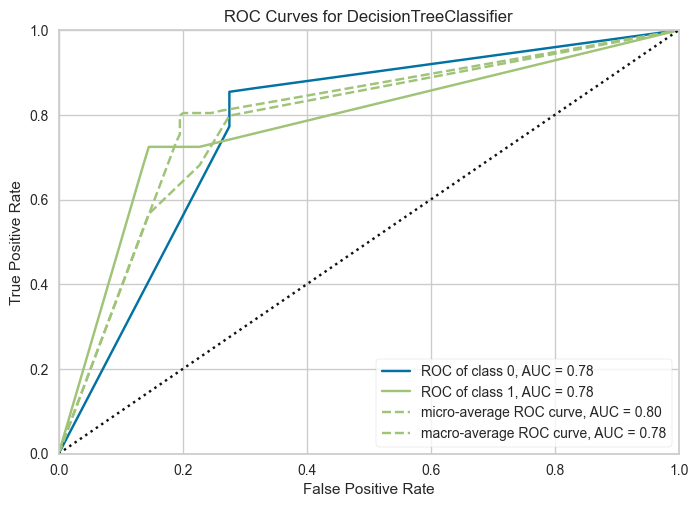

In [12]:
# ── ROC-AUC Curves ───────────────────────────────────────────────

print('=== ROC-AUC — Naive Bayes ===')
plot_model(nb_pyc, plot='auc')

print('=== ROC-AUC — Decision Tree ===')
plot_model(dt_pyc, plot='auc')

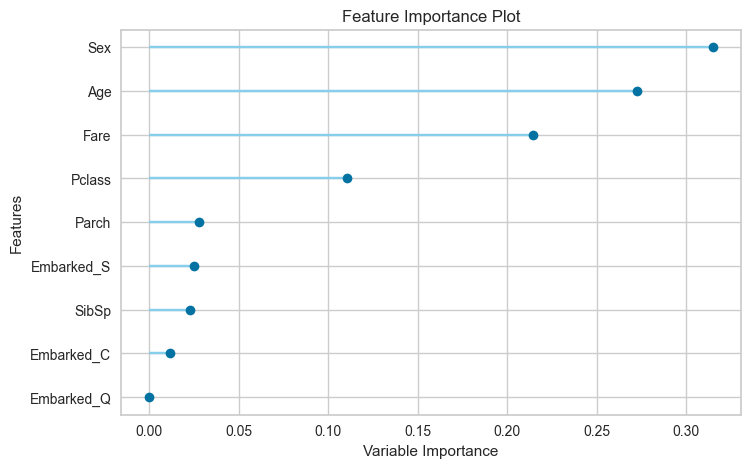

In [13]:
# ── Feature Importance — Decision Tree (PyCaret) ─────────────────

plot_model(dt_pyc, plot='feature')

In [14]:
# ── Final Predictions with Best Model ────────────────────────────

final_model = finalize_model(best_model)
predictions = predict_model(final_model, data=df_pyc)

print('=== Sample Predictions (Best Model) ===')
print(predictions[['Survived', 'prediction_label', 'prediction_score']].head(10))

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.8923,0.9451,0.7953,0.9128,0.8500,0.7666,0.7710


=== Sample Predictions (Best Model) ===
   Survived  prediction_label  prediction_score
0         0                 0            0.8993
1         1                 1            0.9658
2         1                 0            0.5050
3         1                 1            0.9724
4         0                 0            0.8602
5         0                 0            0.8510
6         0                 0            0.8962
7         0                 0            0.9115
8         1                 0            0.5084
9         1                 1            0.9494


---
## Summary

| Part | Algorithm | Dataset | Key Takeaway |
|------|-----------|---------|---------------|
| 1 | Naive Bayes | Play Tennis (14 rows) | Fast, probabilistic; works well even with tiny data |
| 2 | Naive Bayes | Titanic (891 rows) | Feature independence assumption limits accuracy |
| 3 | Decision Tree | Play Tennis (14 rows) | Perfectly interpretable; entropy splits on outlook/humidity |
| 4 | Decision Tree | Titanic (891 rows) | Sex & Fare are most important features |
| 5 | PyCaret AutoML | Titanic (891 rows) | Compares 15+ models automatically; finds best performer |

### Key Concepts Recap
- **Confusion Matrix** — shows TP, TN, FP, FN counts
- **Precision** — of all predicted positives, how many were truly positive?
- **Recall** — of all actual positives, how many did we catch?
- **F1-Score** — harmonic mean of Precision and Recall; balanced metric
- **Naive Bayes** — best when features are independent; very fast
- **Decision Tree** — interpretable; can overfit without pruning (`max_depth`)